In [7]:
from langgraph.graph import StateGraph, START,MessagesState,END
from langgraph.checkpoint.memory import  InMemorySaver
from dotenv import load_dotenv
#using langchains Remove Message class for Deletion
from langchain.messages import RemoveMessage
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
#defining nodes here
def chat(state:MessagesState):
    response = llm.invoke(state['messages'])
    return {'messages':[response]}

#delete old messages
def delete_old_messages(state: MessagesState):
    messages = state['messages']
    #if we have more than 10 messages delete the earliest 6 messages them using Removemessage
    if len(messages) >10:
        to_remove = messages[:6] #to remove old 6 msgs if the count is greater than 10
        return {'messages':[RemoveMessage(id = msg.id) for msg in to_remove]}
    return {}

In [9]:
builder = StateGraph(MessagesState)
builder.add_node('chat',chat)
builder.add_node('cleanup',delete_old_messages)
builder.add_edge(START,'chat')
builder.add_edge('chat','cleanup')
builder.add_edge('cleanup',END)

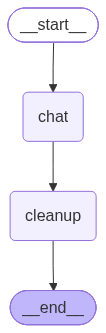

In [10]:
graph = builder.compile(checkpointer=InMemorySaver())
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

In [12]:
#Running multiple times to check the deletion
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nazia"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='33d88a29-72a1-4d5a-b54c-e9810b05aa65'),
  AIMessage(content='Okay, Nazia, let\'s zoom out a bit. If LangGraph is the sophisticated orchestrator for complex LLM applications, then **LangChain** is the foundational framework that provides all the building blocks and initial tools to create those applications in the first place.\n\nThink of it like this:\n\n*   **LangChain is your comprehensive toolkit** for developing applications powered by Large Language Models. It gives you the individual tools and basic assembly instructions.\n*   **LangGraph is a specialized machine built *using* LangChain\'s tools** to handle very specific, complex, and stateful workflows, especially for agents.\n\n---\n\n### What is LangChain?\n\n**LangChain is an open-source framework designed to simplify the creation of applications that leverage Large Language Models (LLMs).** Its core idea is to allow develo

In [13]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
